In [ ]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [ ]:
# LOAD DATASET

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.head())

print(df.info())

print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape


Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target class distribution before encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64


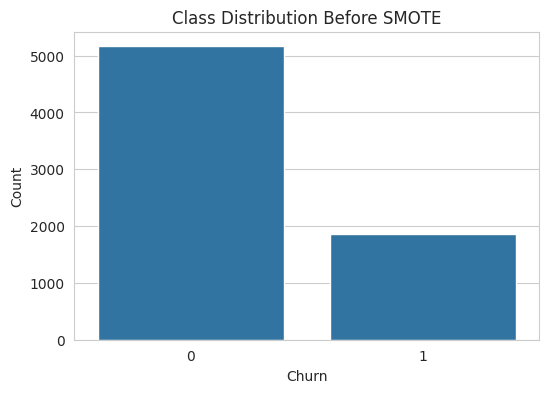


Encoded dataset shape: (7032, 31)


In [ ]:
# DATA PREPROCESSING

df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nTarget class distribution before encoding:")
print(df['Churn'].value_counts())

# Plot class distribution before encoding
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Churn'])
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nEncoded dataset shape:", df_encoded.shape)

In [ ]:
# DEFINE FEATURES AND TARGET
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

feature_names = X.columns

In [ ]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining target distribution before SMOTE:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training target distribution before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [ ]:
# FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training target distribution after SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


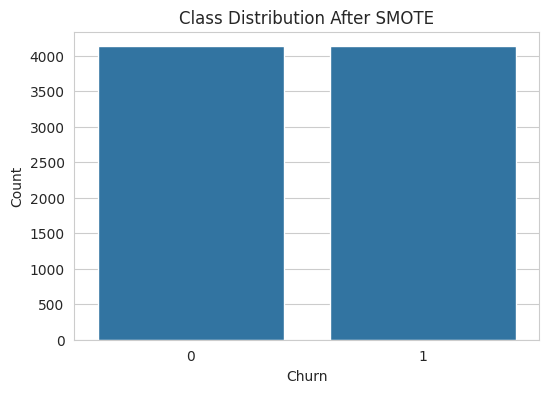

In [ ]:
# APPLY SMOTE TO TRAINING SET ONLY

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nTraining target distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=pd.Series(y_train_smote))
plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [ ]:
# TRAIN LOGISTIC REGRESSION MODEL

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# PREDICTIONS

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# EVALUATION METRICS
train_accuracy = model.score(X_train_smote, y_train_smote)
test_accuracy = accuracy_score(y_test, y_pred)

cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
validation_accuracy = np.mean(cv_scores)

print("\n=========================")
print("MODEL PERFORMANCE")
print("=========================")
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


MODEL PERFORMANCE
Training Accuracy   : 0.7835
Validation Accuracy : 0.7822
Test Accuracy       : 0.7321

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407


Confusion Matrix:
[[738 295]
 [ 82 292]]


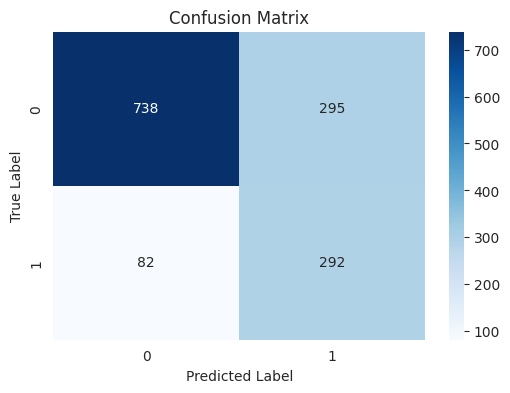

In [ ]:
# CONFUSION MATRIX HEATMAP

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

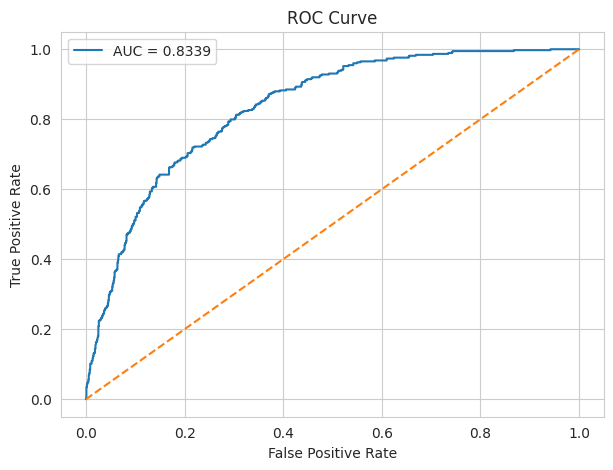


AUC Score: 0.8339


In [ ]:
# ROC CURVE
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"\nAUC Score: {auc_score:.4f}")

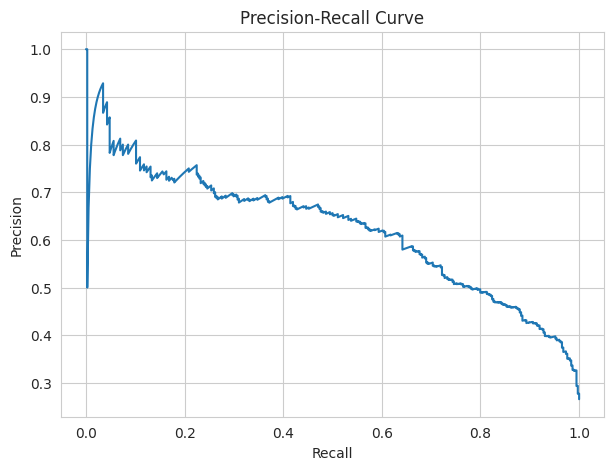

In [ ]:
# PRECISION-RECALL CURVE
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueE

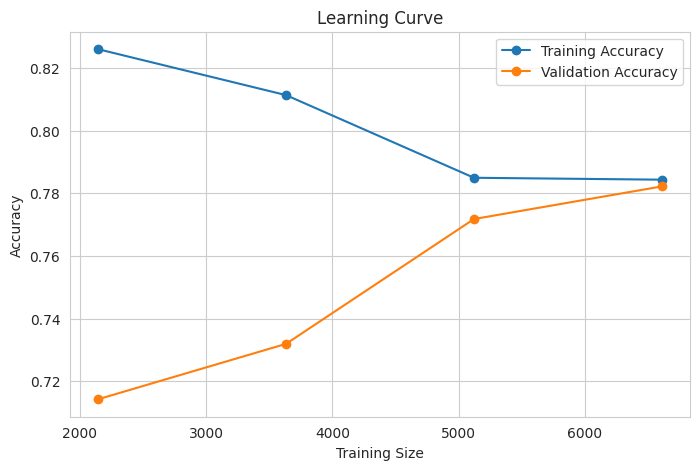

In [ ]:
# LEARNING CURVE

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Accuracy')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


Top 10 Positive Features:
                                  Feature  Coefficient
3                            TotalCharges     0.799716
10            InternetService_Fiber optic     0.788617
23                    StreamingMovies_Yes     0.295393
21                        StreamingTV_Yes     0.243823
9                       MultipleLines_Yes     0.232911
28         PaymentMethod_Electronic check     0.180438
26                   PaperlessBilling_Yes     0.150008
17                   DeviceProtection_Yes     0.082175
27  PaymentMethod_Credit card (automatic)     0.031019
0                           SeniorCitizen     0.030194

Top 10 Negative Features:
                                 Feature  Coefficient
1                                 tenure    -1.485538
2                         MonthlyCharges    -1.035969
25                     Contract_Two year    -0.665843
24                     Contract_One year    -0.345356
13                    OnlineSecurity_Yes    -0.186650
6                

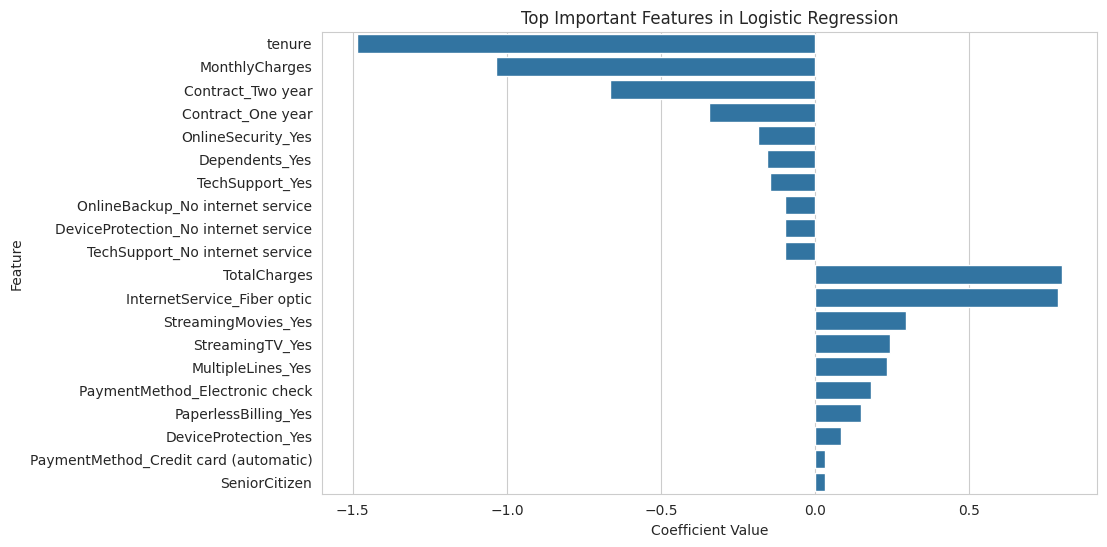

In [ ]:
# FEATURE IMPORTANCE USING COEFFICIENTS

coefficients = model.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Top positive coefficients
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(10)

# Top negative coefficients
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(10)

print("\nTop 10 Positive Features:")
print(top_positive)

print("\nTop 10 Negative Features:")
print(top_negative)

# Plot top 10 positive and negative features
top_features = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title("Top Important Features in Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [ ]:
new_customer_data = {
    'gender_Male': [1],
    'SeniorCitizen': [0],
    'Partner_Yes': [1],
    'Dependents_Yes': [0],
    'tenure': [12],
    'PhoneService_Yes': [1],
    'PaperlessBilling_Yes': [1],
    'MonthlyCharges': [70.5],
    'TotalCharges': [800.2],
    'MultipleLines_Yes': [0],
    'InternetService_Fiber optic': [1],
    'OnlineSecurity_Yes': [0],
    'OnlineBackup_Yes': [1],
    'DeviceProtection_Yes': [0],
    'TechSupport_Yes': [0],
    'StreamingTV_Yes': [1],
    'StreamingMovies_Yes': [1],
    'Contract_One year': [0],
    'Contract_Two year': [0],
    'PaymentMethod_Credit card (automatic)': [0],
    'PaymentMethod_Electronic check': [1],
    'PaymentMethod_Mailed check': [0]
}

# Create a DataFrame with all feature names and initialize with 0
new_data_df = pd.DataFrame(0, index=[0], columns=feature_names)

# Update the values for the provided new customer data
for col, value in new_customer_data.items():
    if col in new_data_df.columns:
        new_data_df[col] = value[0] # value is a list, so take the first element


# Ensure all columns are of the correct numeric type before scaling
# Some columns created by get_dummies might be boolean, convert them to int
for col in new_data_df.columns:
    if new_data_df[col].dtype == 'bool':
        new_data_df[col] = new_data_df[col].astype(int)

new_data_scaled = scaler.transform(new_data_df)

# Make prediction
prediction = model.predict(new_data_scaled)
prediction_proba = model.predict_proba(new_data_scaled)[:, 1]

print(f"Predicted Churn (0=No, 1=Yes): {prediction[0]}")
print(f"Predicted Churn Probability: {prediction_proba[0]:.4f}")

Predicted Churn (0=No, 1=Yes): 1
Predicted Churn Probability: 0.9262


In [ ]:
new_customer_data = {
    'gender_Male': [0],
    'SeniorCitizen': [0],
    'Partner_Yes': [1],
    'Dependents_Yes': [1],
    'tenure': [60],
    'PhoneService_Yes': [1],
    'PaperlessBilling_Yes': [0],
    'MonthlyCharges': [55],
    'TotalCharges': [3200],
    'MultipleLines_Yes': [0],
    'InternetService_Fiber optic': [0],
    'OnlineSecurity_Yes': [1],
    'OnlineBackup_Yes': [1],
    'DeviceProtection_Yes': [1],
    'TechSupport_Yes': [1],
    'StreamingTV_Yes': [0],
    'StreamingMovies_Yes': [0],
    'Contract_One year': [0],
    'Contract_Two year': [1],
    'PaymentMethod_Credit card (automatic)': [1],
    'PaymentMethod_Electronic check': [0],
    'PaymentMethod_Mailed check': [0]
}

# Create a DataFrame with all feature names and initialize with 0
new_data_df = pd.DataFrame(0, index=[0], columns=feature_names)

# Update the values for the provided new customer data
for col, value in new_customer_data.items():
    if col in new_data_df.columns:
        new_data_df[col] = value[0] # value is a list, so take the first element


# Ensure all columns are of the correct numeric type before scaling
# Some columns created by get_dummies might be boolean, convert them to int
for col in new_data_df.columns:
    if new_data_df[col].dtype == 'bool':
        new_data_df[col] = new_data_df[col].astype(int)

new_data_scaled = scaler.transform(new_data_df)

# Make prediction
prediction = model.predict(new_data_scaled)
prediction_proba = model.predict_proba(new_data_scaled)[:, 1]

print(f"Predicted Churn (0=No, 1=Yes): {prediction[0]}")
print(f"Predicted Churn Probability: {prediction_proba[0]:.4f}")

Predicted Churn (0=No, 1=Yes): 0
Predicted Churn Probability: 0.0082
